## Лабораторная 6

1. Необходимо найти датасет на huggingface или kaggle. В датасете обязательно должны быть временные метки.
2. На основе этого датасета необходимо построить рекурсивную или гибридную модель прогнозирования одного из представленных в нем признаков.

**Пример:** 
Набор данных со статистикой по просмотрам видео на YouTube. Можно спрогнозировать будущее количество просмотров видео в зависимости от дня недели, соотношения лайков и дизлайков. Помните, можно опираться на несколько признаков.


In [1]:
import pandas as pd
import numpy as np
from tensorflow import keras
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
from tqdm import tqdm

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
pd.options.mode.chained_assignment = None 

In [16]:
df = pd.read_csv("jena_climate_2009_2016/jena_climate_2009_2016.csv")

# Смотрим датасет

In [17]:
df.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [18]:
df.describe()

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
count,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000
mean,989.212776,9.450147,283.492743,4.955854,76.008259,13.576251,9.533756,4.042412,6.022408,9.640223,1216.062748,1.702224,3.056555,174.743738
std,8.358481,8.423365,8.504471,6.730674,16.476175,7.739020,4.184164,4.896851,2.656139,4.235395,39.975208,65.446714,69.016932,86.681693
min,913.600000,-23.010000,250.600000,-25.010000,12.950000,0.950000,0.790000,0.000000,0.500000,0.800000,1059.450000,-9999.000000,-9999.000000,0.000000
25%,984.200000,3.360000,277.430000,0.240000,65.210000,7.780000,6.210000,0.870000,3.920000,6.290000,1187.490000,0.990000,1.760000,124.900000
50%,989.580000,9.420000,283.470000,5.220000,79.300000,11.820000,8.860000,2.190000,5.590000,8.960000,1213.790000,1.760000,2.960000,198.100000
75%,994.720000,15.470000,289.530000,10.070000,89.400000,17.600000,12.350000,5.300000,7.800000,12.490000,1242.770000,2.860000,4.740000,234.100000
max,1015.350000,37.280000,311.340000,23.110000,100.000000,63.770000,28.320000,46.010000,18.130000,28.820000,1393.540000,28.490000,23.500000,360.000000


In [19]:
df.isna().sum()

Date Time          0
p (mbar)           0
T (degC)           0
Tpot (K)           0
Tdew (degC)        0
rh (%)             0
VPmax (mbar)       0
VPact (mbar)       0
VPdef (mbar)       0
sh (g/kg)          0
H2OC (mmol/mol)    0
rho (g/m**3)       0
wv (m/s)           0
max. wv (m/s)      0
wd (deg)           0
dtype: int64

In [20]:
corr = df.drop(columns=["Date Time"]).corr()
corr.style.background_gradient(cmap="coolwarm", axis=1).format(precision=3)

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
p (mbar),1.000,-0.045,-0.125,-0.067,-0.018,-0.032,-0.054,-0.003,-0.070,-0.070,0.308,-0.006,-0.008,-0.063
T (degC),-0.045,1.000,0.997,0.896,-0.572,0.951,0.868,0.762,0.867,0.867,-0.963,-0.005,-0.003,0.039
Tpot (K),-0.125,0.997,1.000,0.895,-0.567,0.947,0.866,0.757,0.867,0.867,-0.981,-0.004,-0.002,0.044
Tdew (degC),-0.067,0.896,0.895,1.000,-0.157,0.799,0.968,0.436,0.968,0.968,-0.885,-0.009,-0.009,0.050
rh (%),-0.018,-0.572,-0.567,-0.157,1.000,-0.616,-0.151,-0.844,-0.151,-0.151,0.514,-0.005,-0.010,-0.016
VPmax (mbar),-0.032,0.951,0.947,0.799,-0.616,1.000,0.825,0.876,0.824,0.824,-0.902,-0.004,-0.002,-0.010
VPact (mbar),-0.054,0.868,0.866,0.968,-0.151,0.825,1.000,0.449,1.000,1.000,-0.850,-0.010,-0.010,0.018
VPdef (mbar),-0.003,0.762,0.757,0.436,-0.844,0.876,0.449,1.000,0.449,0.449,-0.698,0.002,0.005,-0.031
sh (g/kg),-0.070,0.867,0.867,0.968,-0.151,0.824,1.000,0.449,1.000,1.000,-0.853,-0.009,-0.010,0.019
H2OC (mmol/mol),-0.070,0.867,0.867,0.968,-0.151,0.824,1.000,0.449,1.000,1.000,-0.854,-0.009,-0.010,0.020


# Предобработка

In [21]:
# Обрезаем поломанные значения
df["wv (m/s)"] = df["wv (m/s)"].clip(lower=0.)
df["max. wv (m/s)"] = df["max. wv (m/s)"].clip(lower=0.)

In [22]:
time_markers = df["Date Time"]
df = df.drop(columns=["Date Time"])

In [23]:
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df)
df = pd.DataFrame(scaled, columns=df.columns)

In [24]:
# Смещаем значения на 1, чтобы было, что предсказывать
Y_train = df[1:]
X_train = df[:-1]

In [25]:
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, test_size=0.2, random_state=1337, shuffle=False)

In [26]:
# Будем предсказывать на основании предыдущих 100 измерений
# Создаем view последовательностей длиной в 100 и транспонируем, чтобы shape было (batch_size, window_len, num_of_features)

window_len = 100

X_train_seq = np.lib.stride_tricks.sliding_window_view(X_train, window_shape=window_len, axis=0).transpose(0, 2, 1)
Y_train_seq = np.lib.stride_tricks.sliding_window_view(Y_train, window_shape=window_len, axis=0).transpose(0, 2, 1)
X_val_seq = np.lib.stride_tricks.sliding_window_view(X_val, window_shape=window_len, axis=0).transpose(0, 2, 1)
Y_val_seq = np.lib.stride_tricks.sliding_window_view(Y_val, window_shape=window_len, axis=0).transpose(0, 2, 1)

# Обучаем модель

In [71]:
num_of_features = 14

model = keras.Sequential([
    keras.layers.Input(shape=(window_len, num_of_features)),
    # keras.layers.GRU(10, return_sequences=True, activation="tanh"),
    # keras.layers.GRU(10, return_sequences=True, activation="tanh"),
    keras.layers.GRU(10, return_sequences=True, activation="tanh"),
    keras.layers.Dense(10, activation="tanh"),
    keras.layers.Dense(10, activation="tanh"),
    keras.layers.Dense(num_of_features, activation="tanh")
])

In [72]:
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_12 (GRU)                    │ (None, 100, 10)        │           780 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 100, 10)        │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 100, 10)        │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 100, 14)        │           154 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,154 (4.51 KB)

 Trainable params: 1,154 (4.51 KB)

 Non-trainable params: 0 (0.00 B)

In [73]:
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01),
                loss=keras.losses.MeanSquaredError,
                metrics=[keras.metrics.MeanAbsoluteError])

In [74]:
history = model.fit(X_train_seq, Y_train_seq, validation_data=(X_val_seq, Y_val_seq), 
                    steps_per_epoch=100, batch_size=100, epochs=100, validation_steps=10)

Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - loss: 0.0781 - mean_absolute_error: 0.1905 - val_loss: 0.0056 - val_mean_absolute_error: 0.0479
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.0066 - mean_absolute_error: 0.0517 - val_loss: 0.0024 - val_mean_absolute_error: 0.0319
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0039 - mean_absolute_error: 0.0365 - val_loss: 0.0014 - val_mean_absolute_error: 0.0218
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0030 - mean_absolute_error: 0.0291 - val_loss: 0.0013 - val_mean_absolute_error: 0.0196
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0028 - mean_absolute_error: 0.0268 - val_loss: 0.0012 - val_mean_absolute_error: 0.0189
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0026 - mean_absolute_error: 0.0255 - val_loss: 0.0011 - val_mean_absolute_error: 0.0172
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0025 - mean_absolute_err

C:\Users\pavel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\trainers\epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


Epoch 35/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0018 - mean_absolute_error: 0.0142 - val_loss: 9.3721e-04 - val_mean_absolute_error: 0.0140
Epoch 36/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0019 - mean_absolute_error: 0.0142 - val_loss: 8.9384e-04 - val_mean_absolute_error: 0.0110
Epoch 37/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0018 - mean_absolute_error: 0.0140 - val_loss: 8.7337e-04 - val_mean_absolute_error: 0.0108
Epoch 38/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0018 - mean_absolute_error: 0.0138 - val_loss: 8.9167e-04 - val_mean_absolute_error: 0.0121
Epoch 39/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.0018 - mean_absolute_error: 0.0138 - val_loss: 9.0653e-04 - val_mean_absolute_error: 0.0110
Epoch 40/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.0018 - mean_absolute_error: 0.0139 - val_loss: 9.4603e-04 - val_mean_absolute_error: 0.0124
Epoch 41/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - l

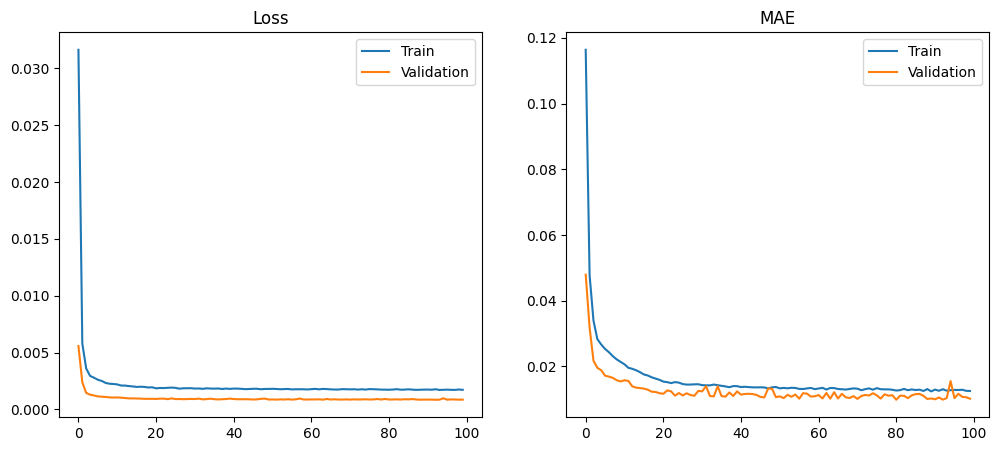

In [75]:
fig = plt.figure(figsize=(12, 5))

fig.add_subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Loss")
plt.legend()

fig.add_subplot(1, 2, 2)
plt.plot(history.history["mean_absolute_error"], label="Train")
plt.plot(history.history["val_mean_absolute_error"], label="Validation")
plt.title("MAE")
plt.legend()

plt.show()

In [76]:
model.evaluate(X_val_seq, Y_val_seq)

2626/2626 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 0.0019 - mean_absolute_error: 0.0130


[0.00174657441675663, 0.012431217357516289]

In [77]:
# Рекурсивно предсказываем значения (потом плотится только температура)

len_of_start = window_len
len_of_predictions = 100
index = 200

start = X_val[index:index+len_of_start]
pred = np.zeros((0, num_of_features))

for i in tqdm(range(len_of_predictions)):
    inp = np.vstack((start[i:], pred))
    inp = np.expand_dims(inp, axis=0)
    new_pred = model.predict(inp, verbose=0)
    pred = np.vstack((pred, new_pred[0, -1]))

100%|██████████| 100/100 [00:11<00:00,  8.64it/s]


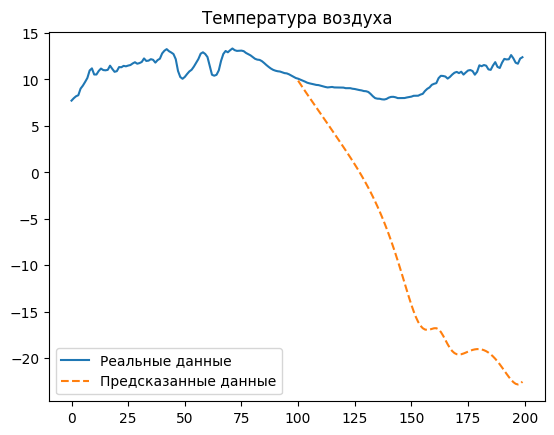

In [78]:
# Отображаем реальное и предсказанное

real = X_val[index:index+len_of_start+len_of_predictions]

real = scaler.inverse_transform(real)
pred = scaler.inverse_transform(pred)

temperature_index = 1
real = real[:, temperature_index]
pred = pred[:, temperature_index]

plt.plot(real, label="Реальные данные", color="tab:blue")
plt.plot(range(len_of_start, len_of_start + len_of_predictions), 
         pred, label="Предсказанные данные", linestyle="--", color="tab:orange")

plt.title("Температура воздуха")
plt.legend()
plt.show()